In [8]:
#Import All essential libaraies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [9]:
#step1:Generate dateaset
np.random.seed(42)
n_students = 100

In [10]:
#study hours between 0 and 42
study=np.random.uniform(0,10,n_students)
print(study)

[3.74540119 9.50714306 7.31993942 5.98658484 1.5601864  1.5599452
 0.58083612 8.66176146 6.01115012 7.08072578 0.20584494 9.69909852
 8.32442641 2.12339111 1.81824967 1.8340451  3.04242243 5.24756432
 4.31945019 2.9122914  6.11852895 1.39493861 2.92144649 3.66361843
 4.56069984 7.85175961 1.99673782 5.14234438 5.92414569 0.46450413
 6.07544852 1.70524124 0.65051593 9.48885537 9.65632033 8.08397348
 3.04613769 0.97672114 6.84233027 4.40152494 1.22038235 4.9517691
 0.34388521 9.09320402 2.58779982 6.62522284 3.11711076 5.20068021
 5.46710279 1.84854456 9.69584628 7.75132823 9.39498942 8.9482735
 5.97899979 9.21874235 0.88492502 1.95982862 0.45227289 3.25330331
 3.8867729  2.71349032 8.28737509 3.56753327 2.8093451  5.42696083
 1.40924225 8.02196981 0.74550644 9.86886937 7.72244769 1.98715682
 0.05522117 8.15461428 7.06857344 7.29007168 7.71270347 0.74044652
 3.58465729 1.1586906  8.63103426 6.23298127 3.30898025 0.6355835
 3.10982322 3.25183322 7.29606178 6.37557471 8.87212743 4.72214925

In [ ]:
# Sigmoid function: calculates probability of passing based on study hours
# At 5 hours: 50% pass probability, more hours = higher probability
def pass_probability(hours):
    return 1 / (1 + np.exp(-(hours - 5)))

In [ ]:
# Calculate pass probability for each student based on their study hours
 #Generate random pass/fail outcomes (0 or 1) using binomial distribution with calculated probabilities
prob_pass = pass_probability(study)
pass_fail = np.random.binomial(1, prob_pass)

In [ ]:
# Create a DataFrame with study hours and pass/fail results
# Display the first 5 rows of the dataset
data=pd.DataFrame({'study':study,'pass':pass_fail})
# Display the first 5 rows of the dataset
data.head()

,study,pass
0,3.745401,0
1,9.507143,1
2,7.319939,1
3,5.986585,1
4,1.560186,0


In [ ]:
# Extract features (independent variable: study hours)
X=data[['study']]
# Extract target (dependent variable: pass/fail outcome)
Y=data['pass']
# Split data into training (80%) and testing (20%) sets with random_state for reproducibility
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
# Create a Logistic Regression model instance
model=LogisticRegression()
# Train the model on the training data
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
# Make binary predictions (0 or 1) on the test data
y_pred=model.predict(X_test)
# Get the probability of class 1 (pass) for each test sample (values between 0 and 1)
y_prob=model.predict_proba(X_test)[:,1]

In [ ]:
# Step 6: Evaluate the model performance on test data
# Calculate accuracy: percentage of correct predictions
print("Accuracy",accuracy_score(y_test,y_pred))
# Confusion Matrix: shows true positives, true negatives, false positives, false negatives
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))
# Classification Report: detailed metrics (precision, recall, f1-score) for each class
print("\n Classificatio Report: \n", classification_report(y_test,y_pred))

Accuracy 0.9

Confusion Matrix:
 [[9 0]
 [2 9]]

 Classificatio Report: 
               precision    recall  f1-score   support

           0       0.82      1.00      0.90         9
           1       1.00      0.82      0.90        11

    accuracy                           0.90        20
   macro avg       0.91      0.91      0.90        20
weighted avg       0.92      0.90      0.90        20



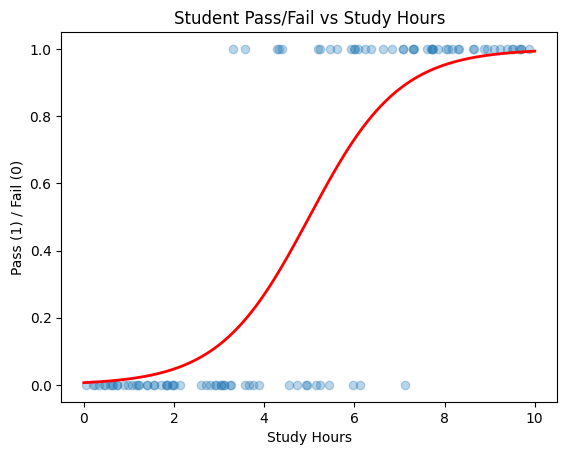

In [ ]:
# Step 7: Visualize the decision boundary (sigmoid curve)
# Plot actual data points with transparency
plt.scatter(data['study'], data['pass'], alpha=0.3)
# Label the x-axis
plt.xlabel('Study Hours')
# Label the y-axis
plt.ylabel('Pass (1) / Fail (0)')
# Add title to the plot
plt.title('Student Pass/Fail vs Study Hours')

# Generate 200 evenly spaced values from 0 to 10 hours for smooth curve
hours_range = np.linspace(0, 10, 200)
# Plot the sigmoid curve (decision boundary) in red to show pass probability
plt.plot(hours_range, pass_probability(hours_range), color='red', linewidth=2)

# Display the plot
plt.show()